# Building segmentation using high resolution satellite imagery

**Dataset description:**

The folder with the dataset includes two study sites (Ventura and Santa-Rosa). RGB channels are in the separate files that are in georeferenced “tif” format. The markup (ground truth labels) is in the “all.tif” file. The spatial resolution (meters in each pixel) equals 0.57 meters. The satellite imagery is obtained from WorldView satellite.

**Task:** There is a binary semantic segmentation task. You are supposed to train a convolutional neural network (CNN) to predict building mask using satellite imagery. The final prediction results should be presented for the test area (you should choose the test area from the dataset) according to the appropriate evaluation metrics.
The solution is expected to be with extension “.py” or “.ipynb”.

**Note:**

Unlike data from the general domain, in Earth remote sensing applications, images are typically up to several thousand pixels both in width and height. Reducing the size of an image so that the neural network model can work with it at the expense of its quality is not always the optimal choice. An alternative approach is to create crops from the initial large satellite image (for instance, 512*512 pixels – you are welcome to choose the size). Then you can handle these smaller patches the same as in the general domain.

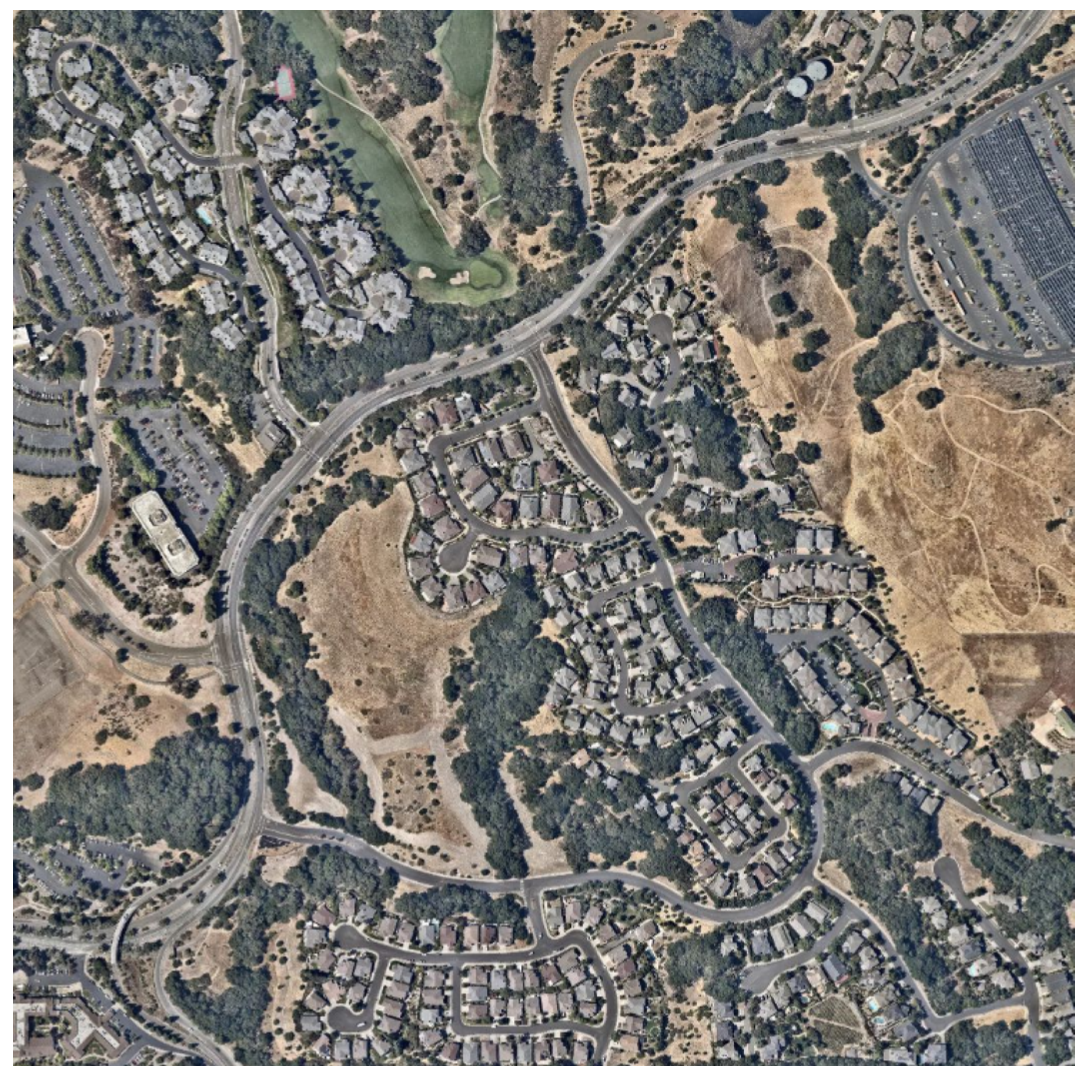

You can split image and it's mask into patches and then train a model to segment each patch.

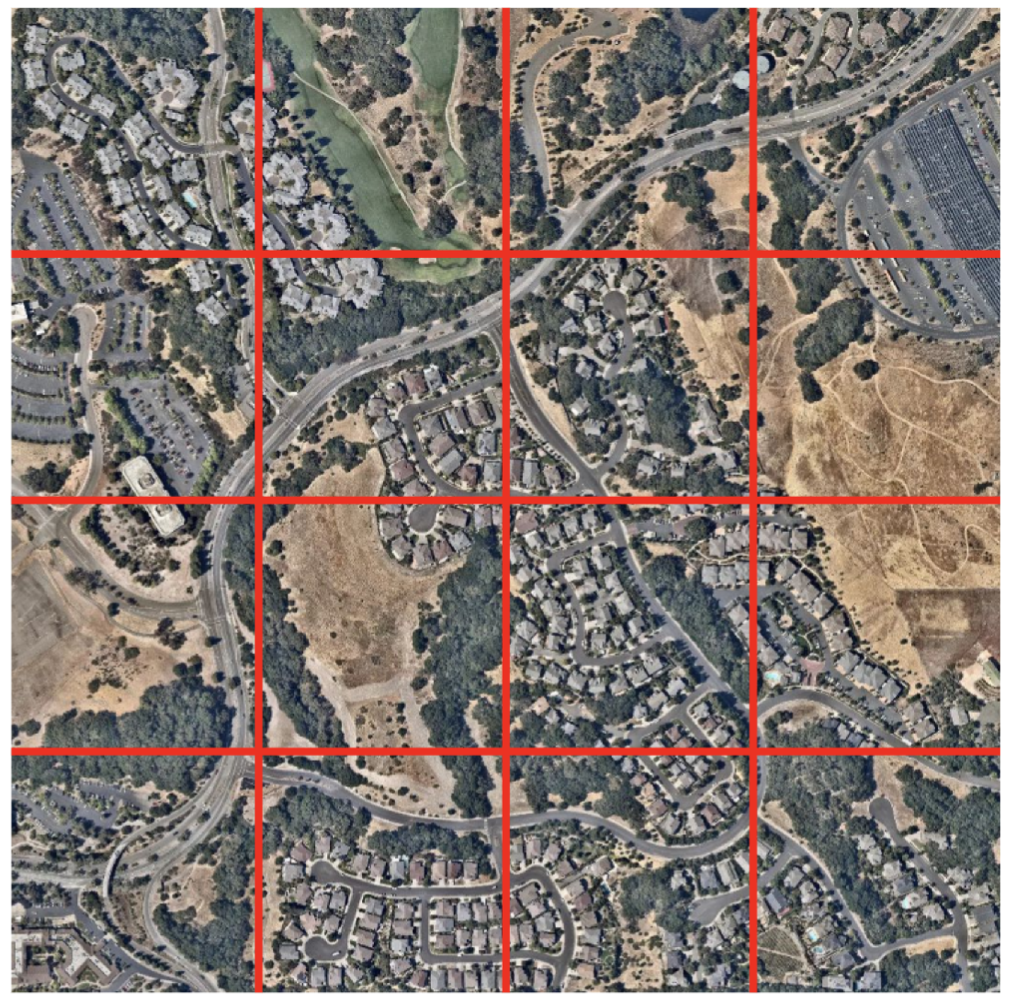

The dataset can be downloaded from the Yandex Disk through the following sript:

In [1]:
# Get the data, unpack it, and remove zip file
# %%capture

! wget https://getfile.dokpub.com/yandex/get/https://disk.yandex.ru/d/xPC1lkuofhVn9Q -O ./building_segmentation.zip
! unzip ./building_segmentation.zip
! rm -f building_segmentation.zip

--2026-04-14 13:33:53--  https://getfile.dokpub.com/yandex/get/https://disk.yandex.ru/d/xPC1lkuofhVn9Q
Распознаётся getfile.dokpub.com (getfile.dokpub.com)… 89.106.78.156
Подключение к getfile.dokpub.com (getfile.dokpub.com)|89.106.78.156|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 302 Found
Адрес: https://downloader.disk.yandex.ru/disk/c6c4f4719b010d3475e03184a3d075ff205693b43926241ed421b59f3d060f6f/69de5053/iqVXsiP3hTJo1tR0fWi9OMJ-OgEq-SrnyDGgDa1OXkoPC21vb7p-8JRQTwjzCJQPsEONOir3pGCjzEUZ1_Pr7A%3D%3D?uid=0&filename=building_segmentation.zip&disposition=attachment&hash=MSlmEP6UdGbog1oRJl5PdkA7YccneHnXbjc8afZyC16qfUxsbaoZRs4Y9nvWV3xlq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=application%2Fzip&owner_uid=106881242&fsize=76586682&hid=acaab0f3d9684ffc73713a548602baf4&media_type=compressed&tknv=v3 [переход]
--2026-04-14 13:33:55--  https://downloader.disk.yandex.ru/disk/c6c4f4719b010d3475e03184a3d075ff205693b43926241ed421b59f3d060f6f/69de5053/iqVXsiP3hTJo

## Data analysis

1. Check the dataset structure

In [ ]:
# your code here

2. Visualize satellite images and markup using tifffile or rasterio libraries for raster georeference files. Check image size.

In [ ]:
! pip install rasterio

In [ ]:
# your code here

3. Count the area (number of pixels) with the target class and the backgound

In [ ]:
# your code here

4. Count the number of individual buildings using OpenCV tools

In [21]:
! pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 41.3 MB/s  0:00:01 eta 0:00:01


In [ ]:
import cv2
import numpy as np

# your code here

## Dataset splitting into train, validation, and test

In [39]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [40]:
def load_tiff_pil(file_path):
    image = Image.open(file_path)
    return np.array(image)

In [41]:
# split dataset into patches

def slice_image(image, size):
    height, width, channels = image.shape
    h_steps = (height + size - 1) // size
    w_steps = (width + size - 1) // size

    patches = []


    for h in range(h_steps):
        for w in range(w_steps):

            start_h = h * size
            start_w = w * size
            end_h = min(start_h + size, height)
            end_w = min(start_w + size, width)


            patch = image[start_h:end_h, start_w:end_w, :]


            if patch.shape[0] < size or patch.shape[1] < size:
                padded_patch = np.zeros((size, size, channels), dtype=patch.dtype)
                padded_patch[:patch.shape[0], :patch.shape[1], :] = patch
                patch = padded_patch

            patches.append(patch)

    return patches


def slice_labels(labels, size):
    height, width = labels.shape
    h_steps = (height + size - 1) // size
    w_steps = (width + size - 1) // size

    label_patches = []

    for h in range(h_steps):
        for w in range(w_steps):
            start_h = h * size
            start_w = w * size
            end_h = min(start_h + size, height)
            end_w = min(start_w + size, width)

            patch = labels[start_h:end_h, start_w:end_w]


            if patch.shape[0] < size or patch.shape[1] < size:
                padded_patch = np.zeros((size, size), dtype=patch.dtype)
                padded_patch[:patch.shape[0], :patch.shape[1]] = patch
                patch = padded_patch

            label_patches.append(patch)

    return label_patches

**Task:** creat new function *patch_slicer* that can work both with images and masks (to replace functions *slice_labels* and *slice_image*).

In [42]:
# your code

In [46]:
def create_dirs(base_dir):
    os.makedirs(base_dir, exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'train/images'), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'train/labels'), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'test/images'), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'test/labels'), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'val/images'), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'val/labels'), exist_ok=True)

def save_patches(patches, labels, split_type, base_dir, prefix, dataset_name):
    for i, (patch, label) in enumerate(zip(patches, labels)):
        img = Image.fromarray(patch)
        img.save(os.path.join(base_dir, f'{split_type}/images/{dataset_name}_{prefix}_{i}.png'))

        label_img = Image.fromarray(label)
        label_img.save(os.path.join(base_dir, f'{split_type}/labels/{dataset_name}_{prefix}_{i}.png'))

In [47]:
datasets = [
    {
        "name": "ventura",
        "red_file": "building_segmentation/ventura/RED.tif",
        "green_file": "building_segmentation/ventura/GRN.tif",
        "blue_file": "building_segmentation/ventura/BLUE.tif",
        "label_file": "building_segmentation/ventura/all.tif"
    },
    {
        "name": "santa_rosa",
        "red_file": "building_segmentation/santa_rosa/RED.tif",
        "green_file": "building_segmentation/santa_rosa/GRN.tif",
        "blue_file": "building_segmentation/santa_rosa/BLUE.tif",
        "label_file": "building_segmentation/santa_rosa/all.tif"
    }
]

base_dir = 'data'
create_dirs(base_dir)

for dataset in datasets:
    red = load_tiff_pil(dataset["red_file"])
    green = load_tiff_pil(dataset["green_file"])
    blue = load_tiff_pil(dataset["blue_file"])
    all_labels = load_tiff_pil(dataset["label_file"])

    rgb_image = np.stack([red, green, blue], axis=-1)

    image_patches = slice_image(rgb_image, size=256)
    label_patches = slice_labels(all_labels, size=256)

    train_images, test_images, train_labels, test_labels = train_test_split(image_patches, label_patches, test_size=0.2, random_state=42)
    val_images, test_images, val_labels, test_labels = train_test_split(test_images, test_labels, test_size=0.50, random_state=42)

    save_patches(train_images, train_labels, 'train', base_dir, 'patch', dataset['name'])
    save_patches(val_images, val_labels, 'val', base_dir, 'patch', dataset['name'])
    save_patches(test_images, test_labels, 'test', base_dir, 'patch', dataset['name'])

**Task:** count number of patches in the train, validation, and test subsets

In [15]:
# your code here
import os

folder_name_list = ['train', 'val', 'test']

for folder_name in folder_name_list:
    print(f'{folder_name} num patches: {len(os.listdir(os.path.join(base_dir, folder_name, 'images')))}')


train num patches: 323
val num patches: 40
test num patches: 42


## Example of Segmentation Dataset class

In [33]:
! pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126 tqdm

Looking in indexes: https://download.pytorch.org/whl/cu126


In [8]:
import numpy as np
import cv2
from torch.utils.data import Dataset
import torch
import os

In [9]:
class SegmentationDataset(Dataset):
    """
    Custom Dataset for image segmentation tasks.

    Each sample consists of:
        - image: input RGB image
        - mask: corresponding segmentation mask

    The dataset assumes that images and masks are stored in separate directories
    and that their filenames are aligned after sorting.
    """
    def __init__(self, image_dir, mask_dir, transform=None):
        """
        Args:
            image_dir (str): Path to directory containing input images.
            mask_dir (str): Path to directory containing segmentation masks.
            transform (callable, optional): Optional transformation applied to the image.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        # List and sort filenames to ensure image-mask alignment.
        # Sorting guarantees that image_paths[i] corresponds to mask_paths[i].
        self.image_paths = sorted(os.listdir(image_dir))
        self.mask_paths = sorted(os.listdir(mask_dir))

        # Optional preprocessing / augmentation function
        self.transform = transform

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        DataLoader uses this to determine the number of batches per epoch.
        """
        return len(self.image_paths)

    def __getitem__(self, idx):
        """
        Returns one sample (image, mask) by index.

        This method is called automatically by DataLoader
        to construct batches during training.
        """

        # Construct full file paths
        image_path = os.path.join(self.image_dir, self.image_paths[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_paths[idx])

        # ---- IMAGE PROCESSING ----

        # Read image using OpenCV (BGR format by default)
        image = cv2.imread(image_path)

        # Convert BGR → RGB because deep learning models expect RGB ordering
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Convert to float32 and normalize pixel values to [0, 1]
        # This improves numerical stability during training.
        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1)) # [H, W, C] -> [C, H, W]

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = mask.astype(np.float32) / 255.0

        # ---- OPTIONAL TRANSFORMS ----

        # Apply additional transformations to image if provided
        # (e.g., augmentations, normalization, etc.)
        if self.transform:
            image = self.transform(image)

        # Ensure mask has shape (1, H, W)
        # If mask is 2D (H, W), add channel dimension.
        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)

        # Convert NumPy arrays to PyTorch tensors
        # dtype=float32 is required for most segmentation losses (e.g., BCE, Dice)    
        mask = torch.tensor(mask, dtype=torch.float32)
        image = torch.tensor(image, dtype=torch.float32)

        return image, mask


In [48]:
train_dataset = SegmentationDataset('data/train/images', 'data/train/labels')
val_dataset = SegmentationDataset('data/val/images', 'data/val/labels')
test_dataset = SegmentationDataset('data/test/images', 'data/test/labels')

In [51]:
len(test_dataset)

42

In [52]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [53]:
def visualize_images_and_masks(dataset, num_images=10):
    plt.figure(figsize=(20, num_images * 3))

    for i in range(num_images):
        image, mask = dataset[i+10]

        if isinstance(image, torch.Tensor):
            image = image.numpy()
        if isinstance(mask, torch.Tensor):
            mask = mask.numpy()


        if image.ndim == 3 and image.shape[0] == 3:
            image = np.transpose(image, (1, 2, 0))
        elif image.ndim == 2:
            image = np.expand_dims(image, axis=-1)

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=-1)


        plt.subplot(num_images, 2, i*2 + 1)
        plt.imshow(image)
        plt.title(f"Image {i+1}")
        plt.axis("off")


        plt.subplot(num_images, 2, i*2 + 2)
        plt.imshow(mask.squeeze(), cmap="gray")
        plt.title(f"Mask {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


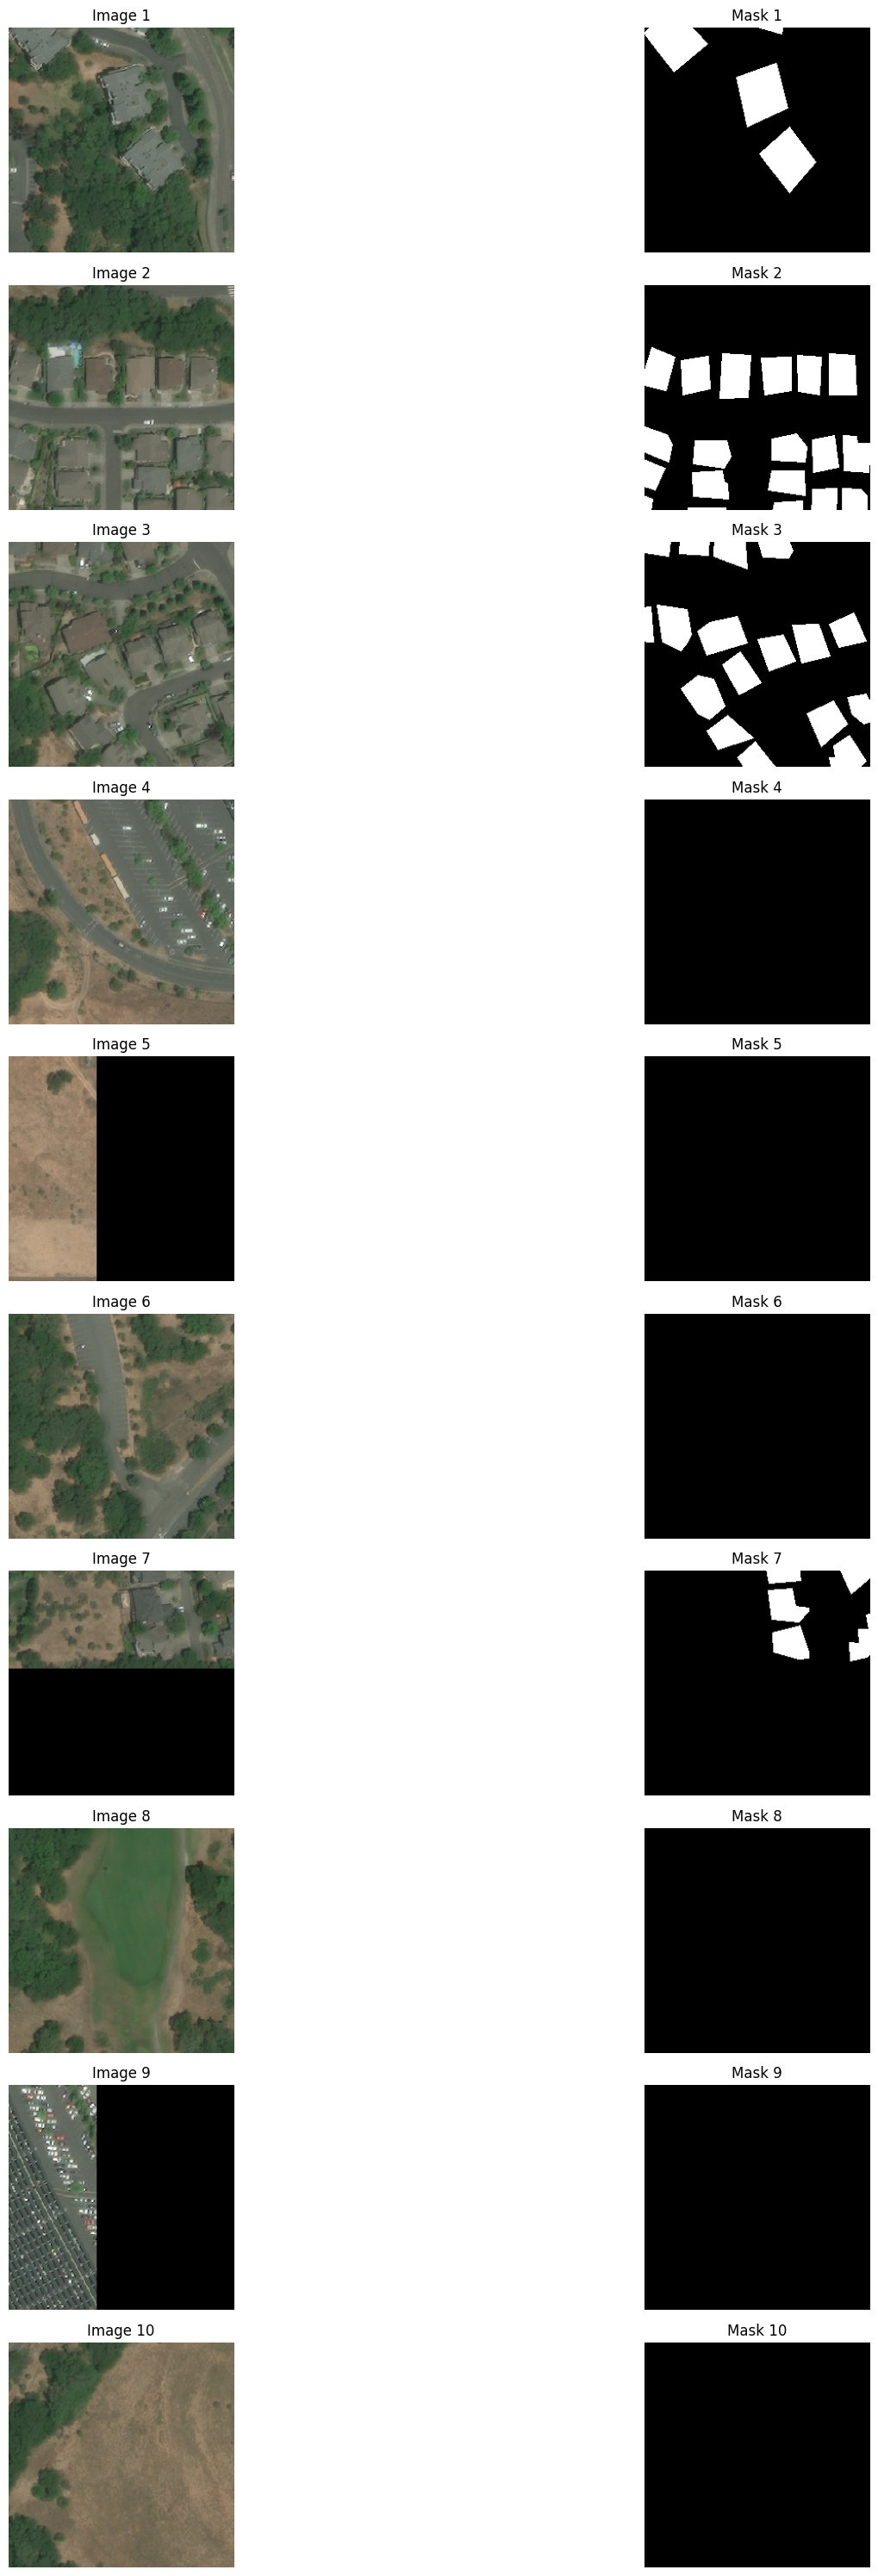

In [54]:
visualize_images_and_masks(train_dataset, num_images=10)

## Simple example of U-Net architecture

In [55]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

![](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

In [58]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        return x

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(EncoderBlock, self).__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv(x)
        p = self.pool(x)
        return x, p

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip_features):
        x = self.upconv(x)
        x = torch.cat((x, skip_features), dim=1)
        x = self.conv(x)
        return x

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        self.encoder1 = EncoderBlock(3, 32)
        self.encoder2 = EncoderBlock(32, 64)
        self.encoder3 = EncoderBlock(64, 128)
        self.encoder4 = EncoderBlock(128, 256)

        self.bottleneck = ConvBlock(256, 512)

        self.decoder1 = DecoderBlock(512, 256)
        self.decoder2 = DecoderBlock(256, 128)
        self.decoder3 = DecoderBlock(128, 64)
        self.decoder4 = DecoderBlock(64, 32)

        self.output_conv = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):

        s1, p1 = self.encoder1(x)
        s2, p2 = self.encoder2(p1)
        s3, p3 = self.encoder3(p2)
        s4, p4 = self.encoder4(p3)


        b1 = self.bottleneck(p4)


        d1 = self.decoder1(b1, s4)
        d2 = self.decoder2(d1, s3)
        d3 = self.decoder3(d2, s2)
        d4 = self.decoder4(d3, s1)


        outputs = torch.sigmoid(self.output_conv(d4)) # maps these values to the range [0, 1], converting them into probabilities.
        return outputs

In [59]:
# initialization and visualization of the architecture

model = UNet()
print(model)

UNet(
  (encoder1): EncoderBlock(
    (conv): ConvBlock(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (encoder2): EncoderBlock(
    (conv): ConvBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (

In [60]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA is available. Device: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print (f"MPS is available.")
else:
    device = torch.device("cpu")
    print("CPU")


MPS is available.


In [62]:
model = UNet().to(device) # moves model weights the selected device 
criterion = nn.BCELoss() # define the loss function: Binary Cross Entropy loss.
optimizer = optim.Adam(model.parameters(), lr=1e-3) # controls how model parameters are updated using gradients computed by backpropagation.

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*0sDDUbXpW0Gie_j4izZTTw.png)

In [63]:
def train(model, dataloader, criterion, optimizer, device):
    # Switch the model to training mode.
    # This activates Dropout and enables BatchNorm to update running statistics.
    model.train()

    total_loss = 0

    for images, masks in tqdm(dataloader):
        # DataLoader provides one batch at a time.
        # images: (B, C, H, W)
        # masks:  (B, 1, H, W)

        # Move tensors to the same device as the model (CPU or GPU).
        images = images.to(device)
        masks = masks.to(device)

        # Clear previously accumulated gradients.
        # Gradients in PyTorch accumulate by default.
        optimizer.zero_grad()

        # Forward pass.
        outputs = model(images)

        # Compute pixel-wise loss.
        # This produces a scalar tensor representing batch loss.
        loss = criterion(outputs, masks)

        # Backpropagation.
        loss.backward()
        # Computes gradients d(loss)/d(parameter) for all model parameters.
        # Gradients are stored in parameter.grad.

        # Update model parameters using computed gradients.
        optimizer.step()
        
        # item() detaches it from the computational graph.
        total_loss += loss.item()

    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    # Switch to evaluation mode.
    # Dropout disabled.
    # BatchNorm uses stored running statistics.

    total_loss = 0

    with torch.no_grad():
    # Disable gradient computation.
    
        for images, masks in tqdm(dataloader):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [64]:
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [65]:
EPOCHS = 10
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"[INFO] Эпоха: {epoch + 1}/{EPOCHS}")

    train_loss = train(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

[INFO] Эпоха: 1/10


100%|██████████| 5/5 [00:00<00:00,  7.04it/s]


Train Loss: 0.4463, Validation Loss: 0.5977
[INFO] Эпоха: 2/10


100%|██████████| 5/5 [00:00<00:00,  7.72it/s]


Train Loss: 0.2748, Validation Loss: 0.3069
[INFO] Эпоха: 3/10


...

Train Loss: 0.1029, Validation Loss: 0.1250
[INFO] Эпоха: 9/10


100%|██████████| 5/5 [00:00<00:00,  8.07it/s]


Train Loss: 0.0893, Validation Loss: 0.1092
[INFO] Эпоха: 10/10


100%|██████████| 5/5 [00:00<00:00,  8.49it/s]

Train Loss: 0.0911, Validation Loss: 0.0970


In [ ]:
EPOCHS = 60
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"[INFO] Эпоха: {epoch + 1}/{EPOCHS}")

    train_loss = train(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

[INFO] Эпоха: 1/60


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  9.46it/s]


Train Loss: 0.4985, Validation Loss: 0.4242
[INFO] Эпоха: 2/60


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  9.79it/s]


Train Loss: 0.3066, Validation Loss: 0.2341
[INFO] Эпоха: 3/60


...

Train Loss: 0.0469, Validation Loss: 0.0829
[INFO] Эпоха: 59/60


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  9.48it/s]


Train Loss: 0.0431, Validation Loss: 0.0815
[INFO] Эпоха: 60/60


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  9.48it/s]

Train Loss: 0.0409, Validation Loss: 0.0761


In [66]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
    plt.plot(val_losses, label='Validation Loss', color='red', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train and Validation Losses')
    plt.legend()
    plt.grid(True)
    plt.show()



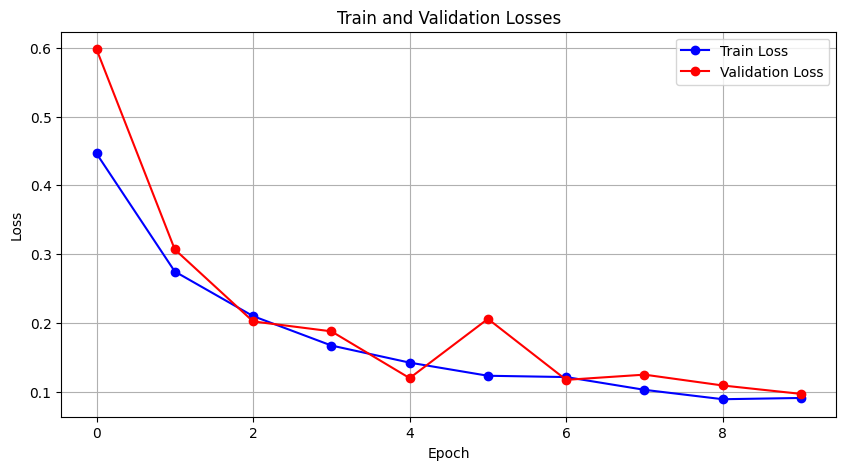

In [67]:
plot_losses(train_losses, val_losses)

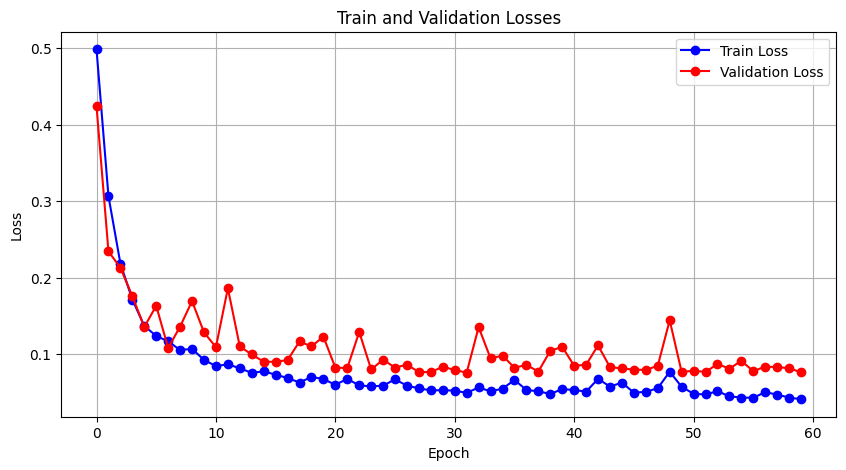

In [ ]:
plot_losses(train_losses, val_losses)

In [29]:
torch.save(model, "unet60")

In [68]:
def test(model, dataloader, criterion, device):
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            test_loss += loss.item()

            preds = (outputs > 0.5).float() # creates a binary mask using a pixel probability threshold.

            all_preds.append(preds.cpu().numpy())
            all_labels.append(masks.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    all_preds = all_preds.flatten()
    all_labels = all_labels.flatten()

    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    avg_loss = test_loss / len(dataloader)
    return avg_loss, precision, recall, f1


test_loss, test_precision, test_recall, test_f1 = test(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}, Test F1 Score: {test_f1:.4f}")



Test Loss: 0.1154, Test Precision: 0.7780, Test Recall: 0.7093, Test F1 Score: 0.7421


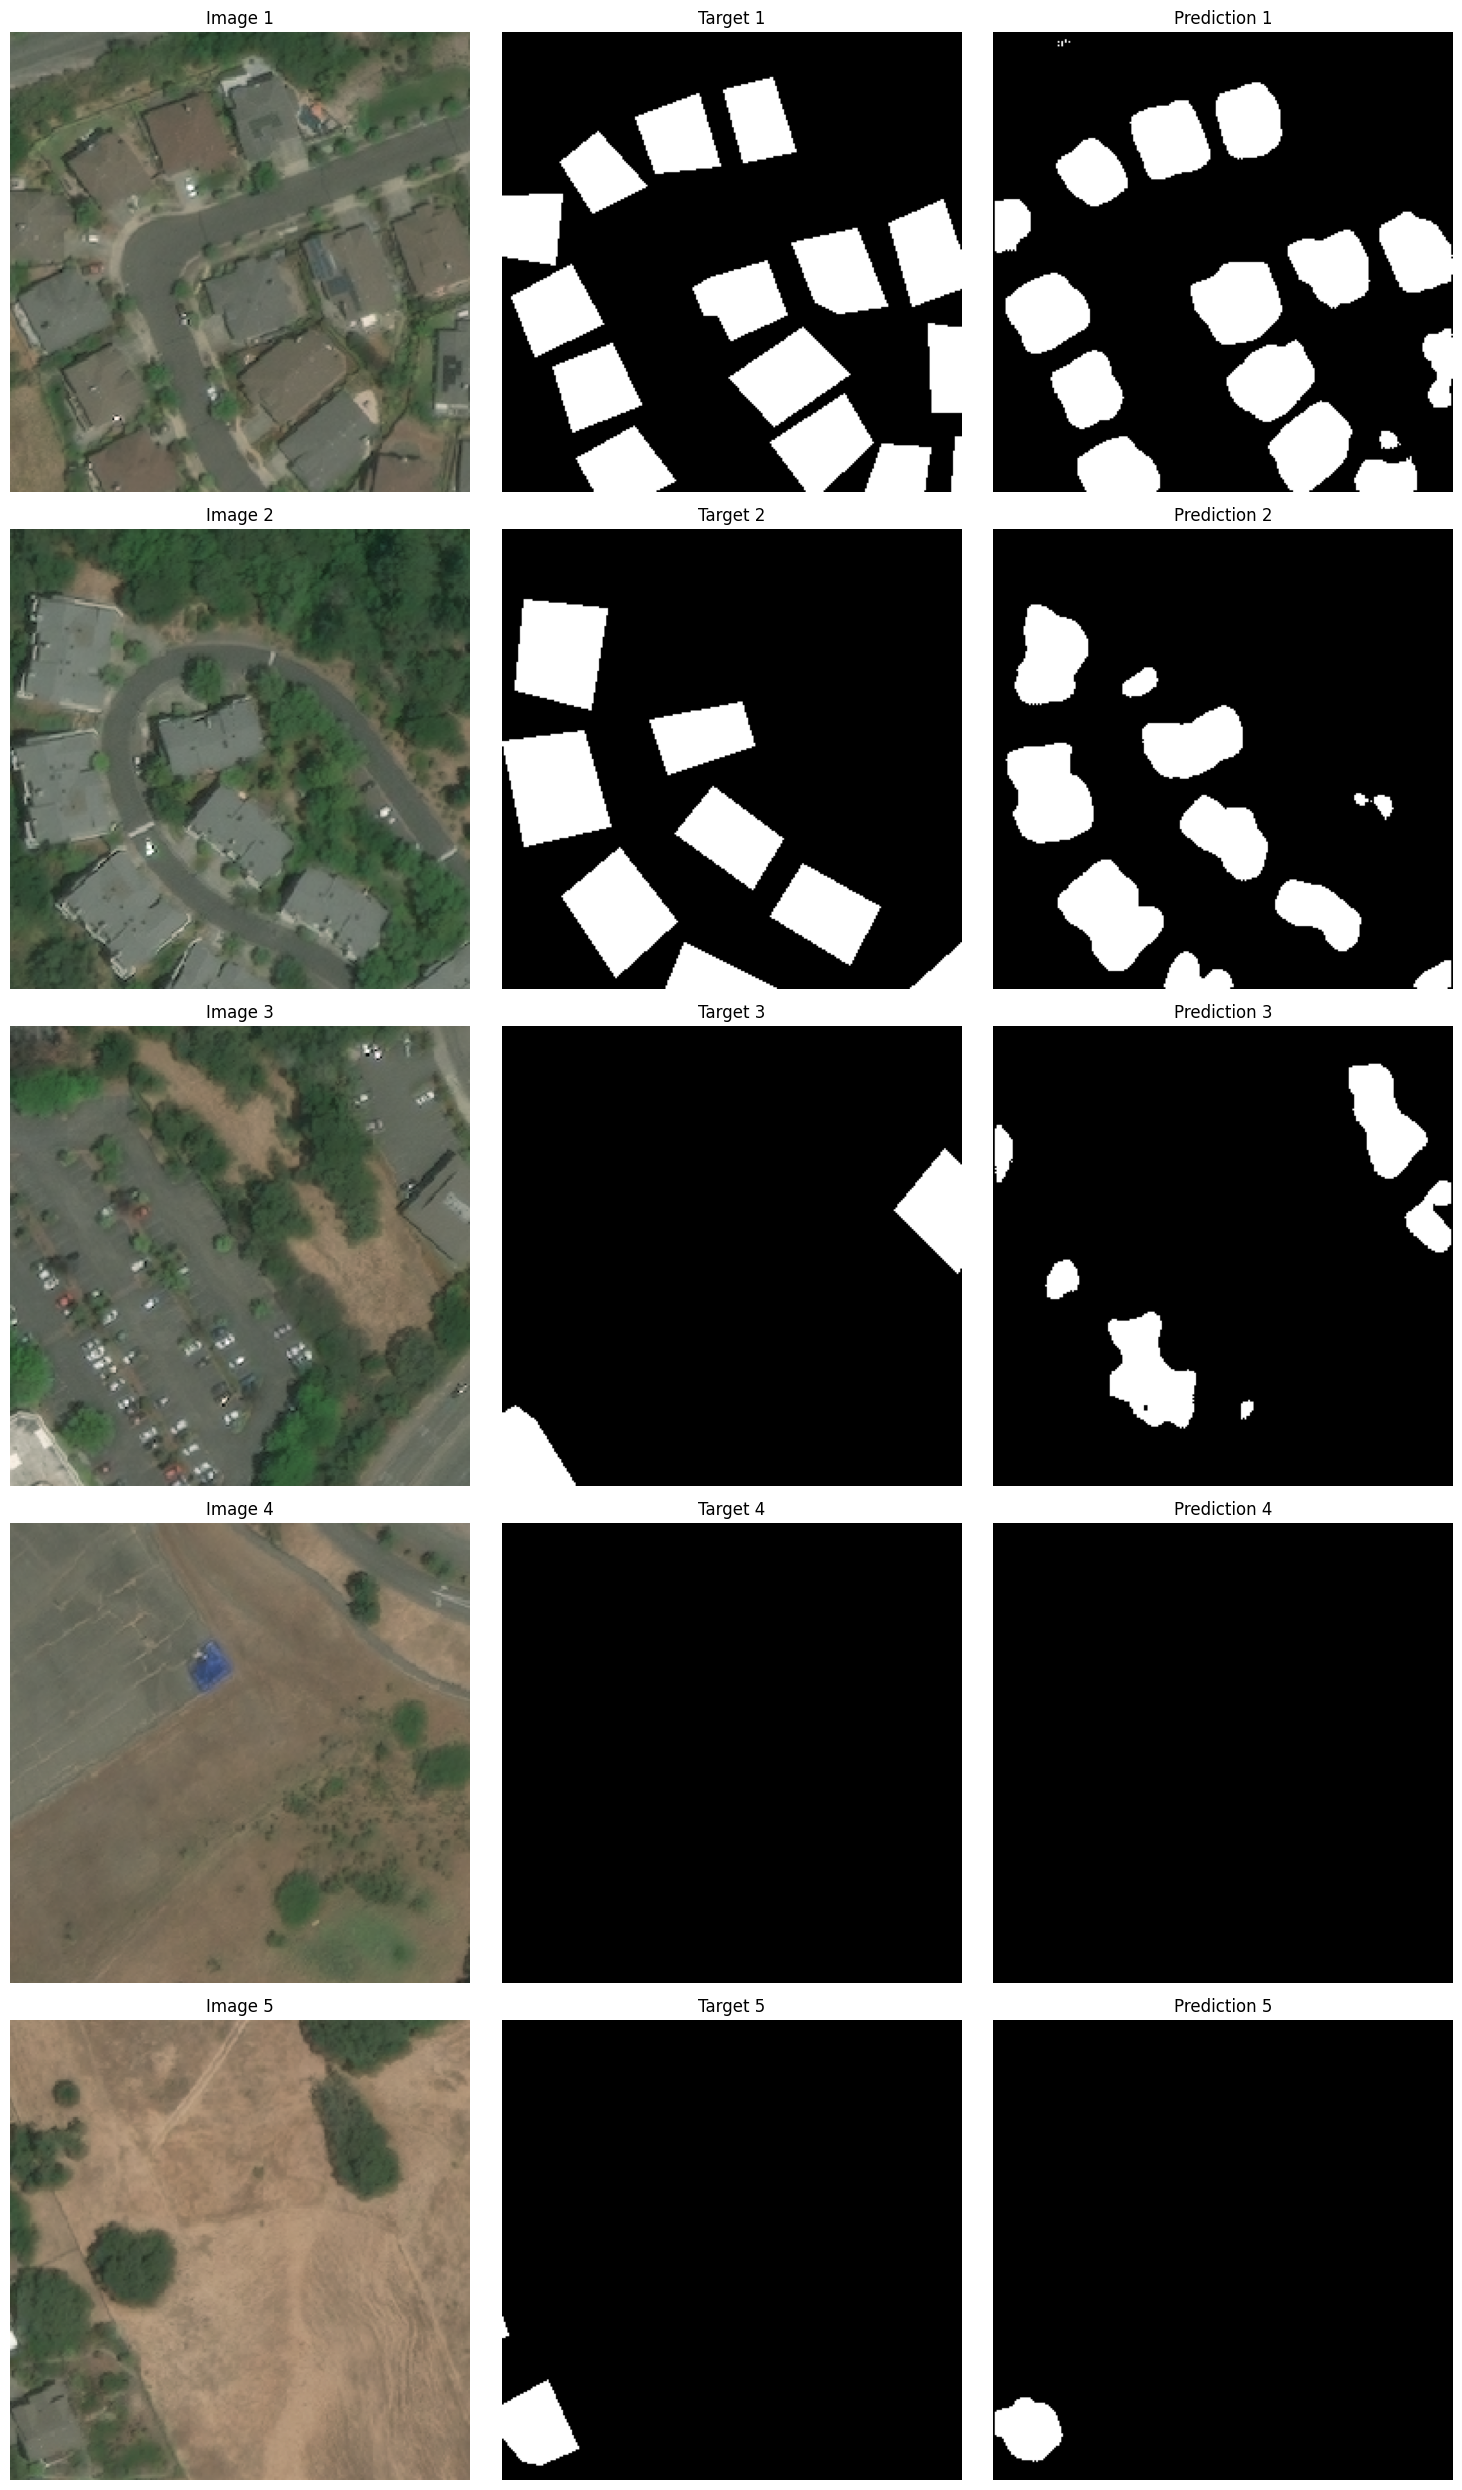

In [70]:
def visualize_segmentation_examples(dataset, model, num_examples=5, device='cpu'):
    model.eval()
    with torch.no_grad():
        plt.figure(figsize=(15, num_examples * 5))
        for i in range(num_examples):

            image, mask = dataset[i]
            image = image.unsqueeze(0).to(device)
            mask = mask.unsqueeze(0).to(device)


            output = model(image)
            pred = (output > 0.5).float()


            image = image.squeeze().cpu().numpy().transpose(1, 2, 0)
            mask = mask.squeeze().cpu().numpy()
            pred = pred.squeeze().cpu().numpy()


            plt.subplot(num_examples, 3, i * 3 + 1)
            plt.imshow(image)
            plt.title(f"Image {i+1}")
            plt.axis("off")

            plt.subplot(num_examples, 3, i * 3 + 2)
            plt.imshow(mask, cmap='gray')
            plt.title(f"Target {i+1}")
            plt.axis("off")

            plt.subplot(num_examples, 3, i * 3 + 3)
            plt.imshow(pred, cmap='gray')
            plt.title(f"Prediction {i+1}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()


visualize_segmentation_examples(test_dataset, model, num_examples=5, device=device)


# Task

1. Create the map with predictions for the entire image (we need to merge patches into a single image).  
2. Try to add augmentations to extend the dataset (use library Albumentations https://github.com/albumentations-team/albumentations)
3. Conduct additional experimnets with other architectures using the library
https://github.com/qubvel-org/segmentation_models.pytorch
